# SVGP LOSO CV — MT, ID, ND, SD, WY

Stochastic Variational GP with mini-batch training on **all** observations.
Sweeps over inducing point counts to characterize the accuracy-speed tradeoff,
then compares to the exact GP baseline (daily batch SGD).

**Kernel:** `Base_RBF_ARD + AOT×Season + SmogI/P×Season + Residual_Season` (same as baseline)

**Key difference from baseline:** SVGP uses all ~48k training observations per fold
via mini-batch optimization of the variational ELBO, rather than subsampling or
daily batching through ExactGP.

In [1]:
# Training already completed — results loaded from saved files
# To re-run: python loso_cv_svgp_parallel.py --n_inducing 128,256,512,1024 \
#   --n_epochs 50 --batch_size 2048 --patience 15 --lr 0.01 --n_gpus 8
print("Loading pre-computed results...")

Loading pre-computed results...


## SVGP Results

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('svgp_results.json') as f:
    results = json.load(f)

summary_df = pd.read_csv('svgp_summary.csv')
site_df = pd.read_csv('svgp_site_metrics.csv')
timing_df = pd.read_csv('svgp_fold_timings.csv')
data = np.load('svgp_predictions.npz')

c = results['config']
print('=' * 70)
print('SVGP LOSO CV Results (MT/ID/ND/SD/WY)')
print('=' * 70)
print(f"Training: {c['training']}, batch_size={c['batch_size']}, lr={c['lr']}")
print(f"Epochs: {c['n_epochs']}, patience={c['patience']}")
print(f"Inducing points swept: {c['inducing_list']}")
print(f"States: {c['states']}")
print(f"Total CV time: {results['total_cv_time']:.1f}s ({results['total_cv_time']/60:.1f} min)")
print()

print(f"{'M':>6} {'RMSE_log':>10} {'MAE_log':>10} {'R²_log':>10} {'RMSE_orig':>10} {'R²_orig':>10} {'train/fold':>12} {'infer/fold':>12}")
print('-' * 88)
for _, row in summary_df.iterrows():
    print(f"{row['n_inducing']:>6.0f} {row['rmse_log']:>10.4f} {row['mae_log']:>10.4f} "
          f"{row['r2_log']:>10.4f} {row['rmse_orig']:>10.2f} {row['r2_orig']:>10.4f} "
          f"{row['mean_train_time']:>11.2f}s {row['mean_infer_time']:>11.3f}s")

SVGP LOSO CV Results (MT/ID/ND/SD/WY)
Training: svgp_minibatch, batch_size=2048, lr=0.01
Epochs: 50, patience=15
Inducing points swept: [128, 256, 512, 1024]
States: ['MT', 'ID', 'ND', 'SD', 'WY']
Total CV time: 17054.5s (284.2 min)

     M   RMSE_log    MAE_log     R²_log  RMSE_orig    R²_orig   train/fold   infer/fold
----------------------------------------------------------------------------------------
   128     0.5396     0.4162     0.4143       4.59     0.4383      107.25s       0.031s
   256     0.5576     0.4302     0.3746       4.70     0.4103      105.77s       0.030s
   512     0.5850     0.4493     0.3116       4.97     0.3414      110.98s       0.035s
  1024     0.5983     0.4583     0.2798       5.10     0.3064      145.38s       0.040s


## Inducing Point Sweep

How do accuracy and cost scale with the number of inducing points?

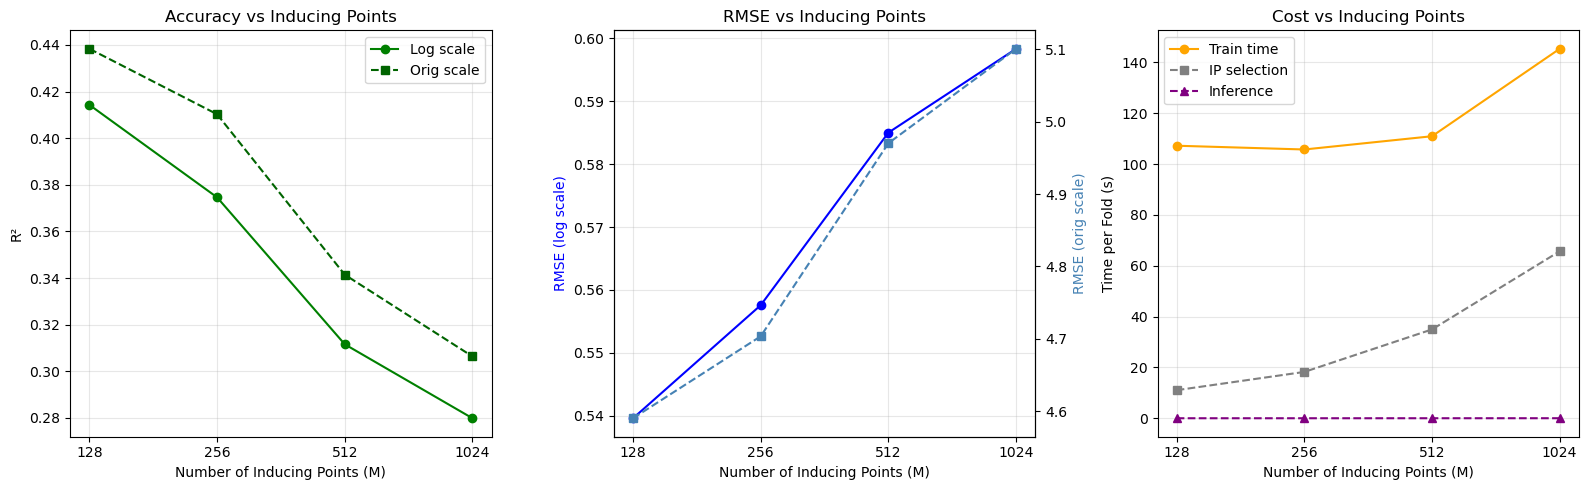

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² vs inducing points
axes[0].plot(summary_df['n_inducing'], summary_df['r2_log'], 'o-', color='green', label='Log scale')
axes[0].plot(summary_df['n_inducing'], summary_df['r2_orig'], 's--', color='darkgreen', label='Orig scale')
axes[0].set_xlabel('Number of Inducing Points (M)')
axes[0].set_ylabel('R²')
axes[0].set_title('Accuracy vs Inducing Points')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log', base=2)
axes[0].set_xticks(summary_df['n_inducing'])
axes[0].set_xticklabels(summary_df['n_inducing'].astype(int))

# RMSE vs inducing points
axes[1].plot(summary_df['n_inducing'], summary_df['rmse_log'], 'o-', color='blue', label='Log scale')
ax1b = axes[1].twinx()
ax1b.plot(summary_df['n_inducing'], summary_df['rmse_orig'], 's--', color='steelblue', label='Orig scale')
ax1b.set_ylabel('RMSE (orig scale)', color='steelblue')
axes[1].set_xlabel('Number of Inducing Points (M)')
axes[1].set_ylabel('RMSE (log scale)', color='blue')
axes[1].set_title('RMSE vs Inducing Points')
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log', base=2)
axes[1].set_xticks(summary_df['n_inducing'])
axes[1].set_xticklabels(summary_df['n_inducing'].astype(int))

# Training time vs inducing points
axes[2].plot(summary_df['n_inducing'], summary_df['mean_train_time'], 'o-', color='orange', label='Train time')
axes[2].plot(summary_df['n_inducing'], summary_df['mean_ip_time'], 's--', color='gray', label='IP selection')
axes[2].plot(summary_df['n_inducing'], summary_df['mean_infer_time'], '^--', color='purple', label='Inference')
axes[2].set_xlabel('Number of Inducing Points (M)')
axes[2].set_ylabel('Time per Fold (s)')
axes[2].set_title('Cost vs Inducing Points')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xscale('log', base=2)
axes[2].set_xticks(summary_df['n_inducing'])
axes[2].set_xticklabels(summary_df['n_inducing'].astype(int))

plt.tight_layout()
plt.show()

## Per-State Accuracy by Inducing Points

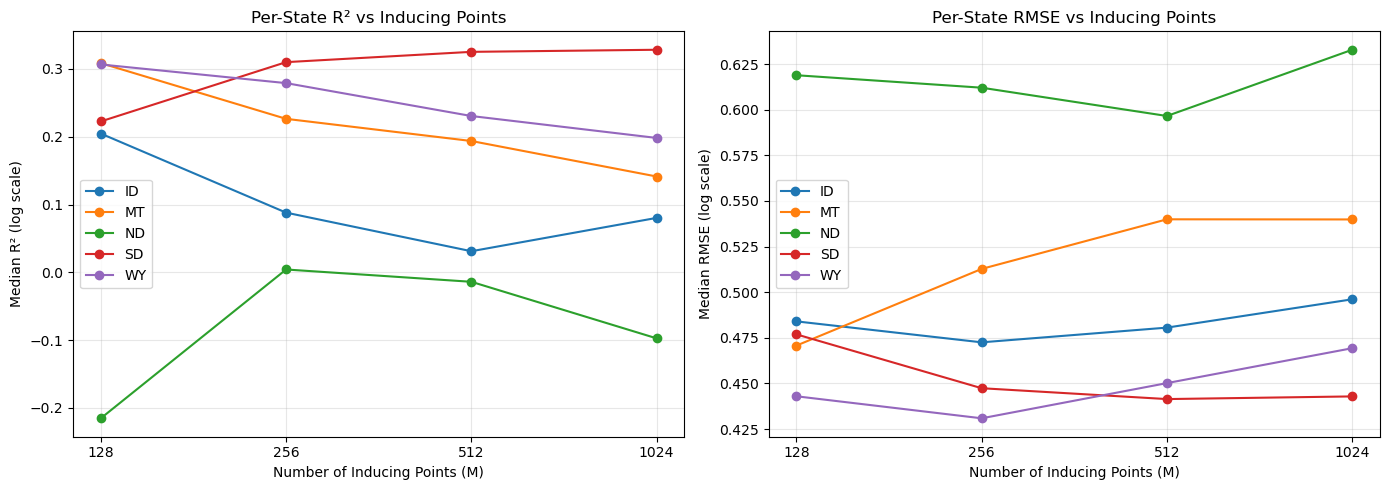


Per-state summary at M=1024:
 State  Sites   Med R²   Med RMSE  Mean R²
------------------------------------------
    ID     38    0.080     0.4961   -1.290
    MT     32    0.141     0.5398   -1.754
    ND      6   -0.097     0.6328   -0.208
    SD      2    0.328     0.4429    0.328
    WY     34    0.198     0.4693    0.076


In [4]:
states = sorted(site_df['state'].unique())
inducing_list = sorted(site_df['n_inducing'].unique())
colors = plt.cm.tab10(range(len(states)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, st in enumerate(states):
    st_data = site_df[site_df['state'] == st]
    st_agg = st_data.groupby('n_inducing').agg(
        median_r2=('r2_log', 'median'),
        median_rmse=('rmse_log', 'median'),
    ).reset_index()
    axes[0].plot(st_agg['n_inducing'], st_agg['median_r2'], 'o-', label=st, color=colors[i])
    axes[1].plot(st_agg['n_inducing'], st_agg['median_rmse'], 'o-', label=st, color=colors[i])

axes[0].set_xlabel('Number of Inducing Points (M)')
axes[0].set_ylabel('Median R² (log scale)')
axes[0].set_title('Per-State R² vs Inducing Points')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log', base=2)
axes[0].set_xticks(inducing_list)
axes[0].set_xticklabels(inducing_list)

axes[1].set_xlabel('Number of Inducing Points (M)')
axes[1].set_ylabel('Median RMSE (log scale)')
axes[1].set_title('Per-State RMSE vs Inducing Points')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log', base=2)
axes[1].set_xticks(inducing_list)
axes[1].set_xticklabels(inducing_list)

plt.tight_layout()
plt.show()

# Table: per-state summary at largest M
max_m = max(inducing_list)
print(f"\nPer-state summary at M={max_m}:")
print(f"{'State':>6} {'Sites':>6} {'Med R²':>8} {'Med RMSE':>10} {'Mean R²':>8}")
print('-' * 42)
for st in states:
    st_data = site_df[(site_df['state'] == st) & (site_df['n_inducing'] == max_m)]
    print(f"{st:>6} {len(st_data):>6} {st_data['r2_log'].median():>8.3f} "
          f"{st_data['rmse_log'].median():>10.4f} {st_data['r2_log'].mean():>8.3f}")

## Predictions (largest M)

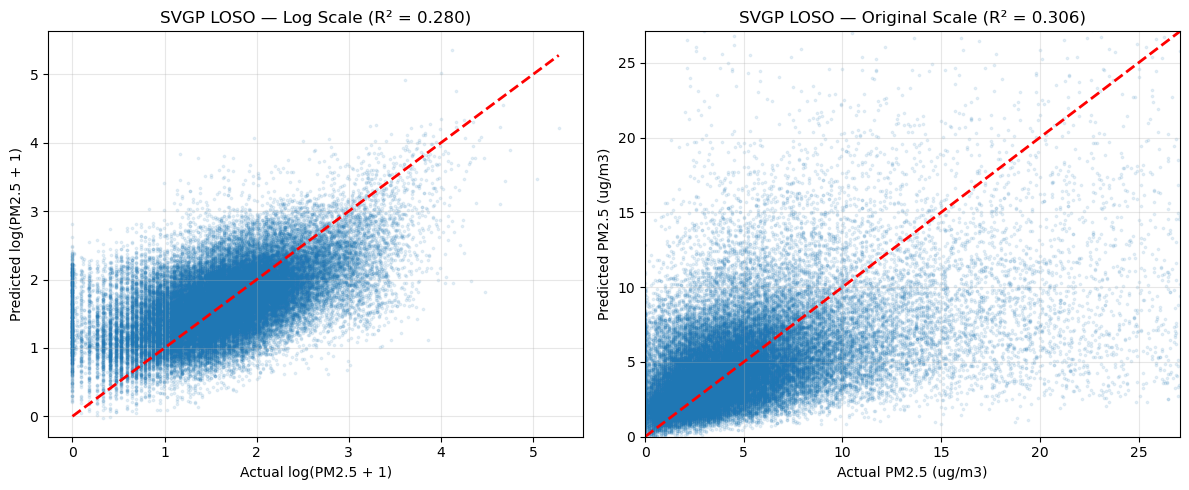

In [5]:
all_pred = data['predictions']
all_actual = data['actuals']
pred_pm25 = data['pred_pm25']
actual_pm25 = data['actual_pm25']

# Overall metrics for largest M
rmse_log = np.sqrt(np.mean((all_pred - all_actual)**2))
r2_log = 1 - np.sum((all_actual - all_pred)**2) / np.sum((all_actual - np.mean(all_actual))**2)
rmse_orig = np.sqrt(np.mean((pred_pm25 - actual_pm25)**2))
r2_orig = 1 - np.sum((actual_pm25 - pred_pm25)**2) / np.sum((actual_pm25 - np.mean(actual_pm25))**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_actual, all_pred, alpha=0.1, s=3)
axes[0].plot([all_actual.min(), all_actual.max()],
             [all_actual.min(), all_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'SVGP LOSO — Log Scale (R² = {r2_log:.3f})')
axes[0].grid(True, alpha=0.3)

max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.1, s=3)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (ug/m3)')
axes[1].set_ylabel('Predicted PM2.5 (ug/m3)')
axes[1].set_title(f'SVGP LOSO — Original Scale (R² = {r2_orig:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Site-Level Analysis

/tmp/ipykernel_2731730/853267369.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(state_r2_data, labels=states, patch_artist=True)


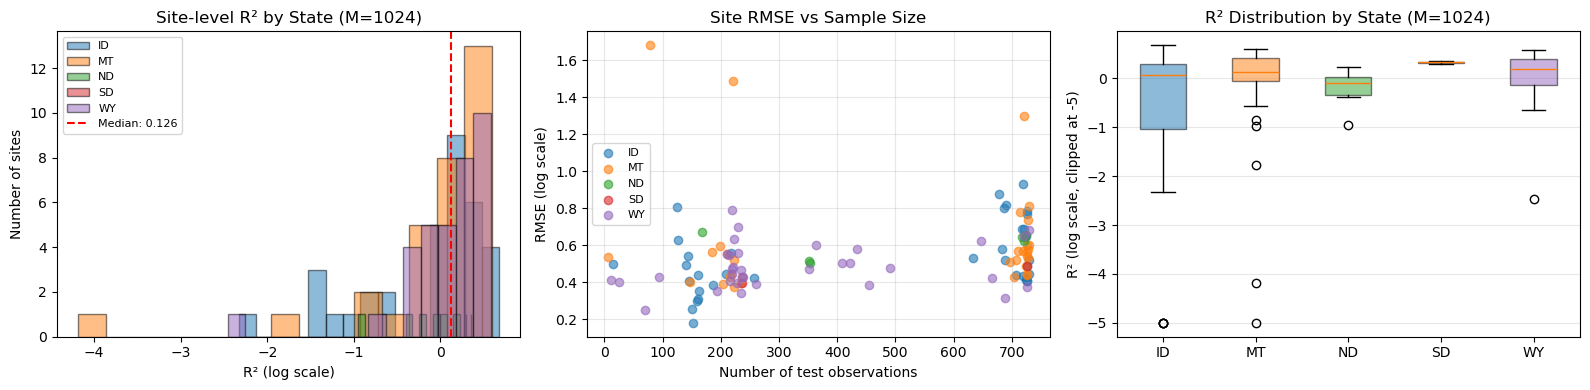

Site-level R² summary (M=1024):
count    112.000000
mean      -0.921034
std        5.544946
min      -54.181853
25%       -0.241701
50%        0.126215
75%        0.378627
max        0.680999
Name: r2_log, dtype: float64

Top 5 best sites:
        site state  n_test  rmse_log   r2_log
116536_46335    ID     257  0.421385 0.680999
114928_44170    ID     186  0.387678 0.603727
108720_47582    MT     222  0.372927 0.595666
108720_42530    WY     726  0.374010 0.582838
109759_42975    WY     216  0.407216 0.582113

Top 5 worst sites:
        site state  n_test  rmse_log     r2_log
115195_48971    MT      78  1.680091 -54.181853
116979_44262    ID     141  0.493449 -14.503742
116359_48894    ID     124  0.807160 -11.817346
116359_48998    ID     126  0.629920 -11.452111
113787_42608    ID     161  0.312322  -5.920234


In [6]:
max_m = max(inducing_list)
site_max = site_df[site_df['n_inducing'] == max_m].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# R² distribution by state
for i, st in enumerate(states):
    st_r2 = site_max[site_max['state'] == st]['r2_log'].dropna()
    st_r2_clipped = st_r2[st_r2 > -5]
    axes[0].hist(st_r2_clipped, bins=15, alpha=0.5, label=st, color=colors[i], edgecolor='black')
axes[0].axvline(x=site_max['r2_log'].median(), color='r', linestyle='--',
                label=f'Median: {site_max["r2_log"].median():.3f}')
axes[0].set_xlabel('R² (log scale)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title(f'Site-level R² by State (M={max_m})')
axes[0].legend(fontsize=8)

# RMSE vs sample size
for i, st in enumerate(states):
    mask = site_max['state'] == st
    axes[1].scatter(site_max.loc[mask, 'n_test'], site_max.loc[mask, 'rmse_log'],
                    alpha=0.6, label=st, color=colors[i])
axes[1].set_xlabel('Number of test observations')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('Site RMSE vs Sample Size')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Box plot of R² by state
state_r2_data = [site_max[site_max['state'] == st]['r2_log'].clip(lower=-5).values
                 for st in states]
bp = axes[2].boxplot(state_r2_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[2].set_ylabel('R² (log scale, clipped at -5)')
axes[2].set_title(f'R² Distribution by State (M={max_m})')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Site-level R² summary (M={max_m}):')
print(site_max['r2_log'].describe())
print()
print('Top 5 best sites:')
print(site_max.nlargest(5, 'r2_log')[['site', 'state', 'n_test', 'rmse_log', 'r2_log']].to_string(index=False))
print()
print('Top 5 worst sites:')
print(site_max.nsmallest(5, 'r2_log')[['site', 'state', 'n_test', 'rmse_log', 'r2_log']].to_string(index=False))

## Training Convergence

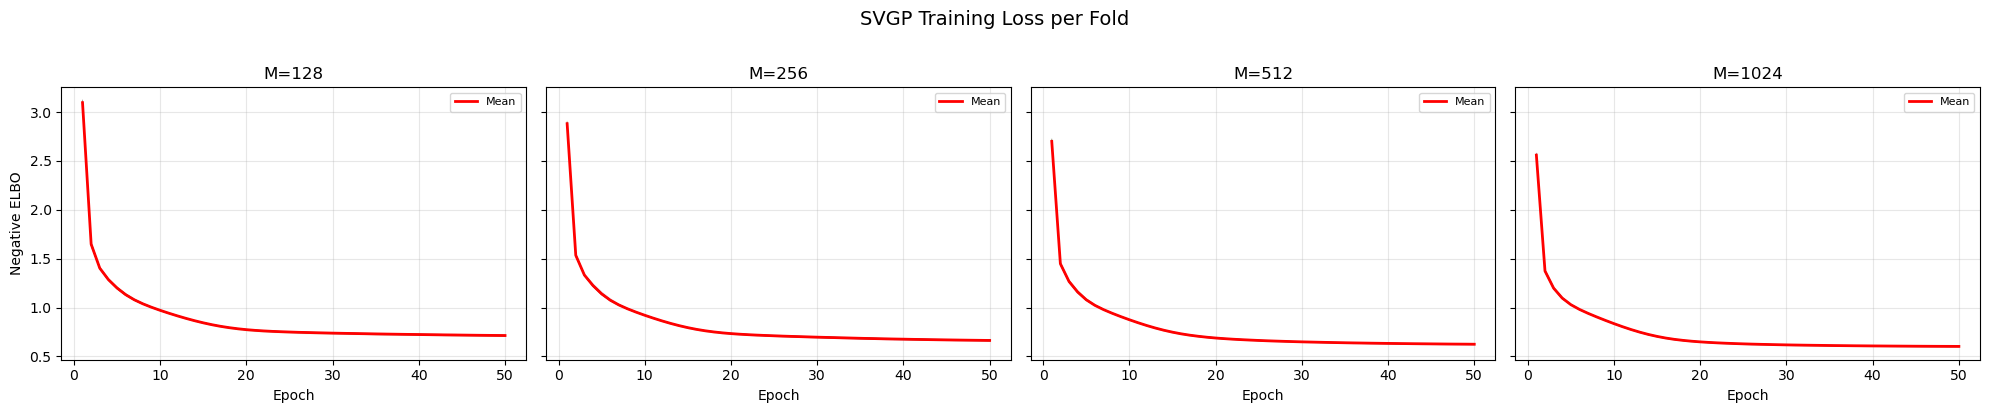

Early stopping summary:
     M   Mean Epoch    Min    Max  Hit Max
------------------------------------------
   128         50.0     50     50      112
   256         50.0     50     50      112
   512         50.0     50     50      112
  1024         50.0     50     50      112


In [7]:
with open('svgp_fold_losses.json') as f:
    fold_losses = json.load(f)

inducing_list_sorted = sorted(inducing_list)
n_m = len(inducing_list_sorted)

fig, axes = plt.subplots(1, n_m, figsize=(5 * n_m, 4), sharey=True)
if n_m == 1:
    axes = [axes]

for ax, m in zip(axes, inducing_list_sorted):
    suffix = f'_M{m}'
    m_losses = {k: v for k, v in fold_losses.items() if k.endswith(suffix)}
    for site, losses in m_losses.items():
        ax.plot(range(1, len(losses) + 1), losses, alpha=0.15, linewidth=0.5)

    # Mean loss curve
    if m_losses:
        max_len = max(len(v) for v in m_losses.values())
        loss_matrix = np.full((len(m_losses), max_len), np.nan)
        for i, losses in enumerate(m_losses.values()):
            loss_matrix[i, :len(losses)] = losses
        mean_loss = np.nanmean(loss_matrix, axis=0)
        ax.plot(range(1, len(mean_loss) + 1), mean_loss, 'r-', linewidth=2, label='Mean')

    ax.set_xlabel('Epoch')
    ax.set_title(f'M={m}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Negative ELBO')
plt.suptitle('SVGP Training Loss per Fold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Stopped epoch summary per M
print("Early stopping summary:")
print(f"{'M':>6} {'Mean Epoch':>12} {'Min':>6} {'Max':>6} {'Hit Max':>8}")
print('-' * 42)
for m in inducing_list_sorted:
    t = timing_df[timing_df['n_inducing'] == m]
    hit_max = (t['stopped_epoch'] == c['n_epochs']).sum()
    print(f"{m:>6} {t['stopped_epoch'].mean():>12.1f} {t['stopped_epoch'].min():>6} "
          f"{t['stopped_epoch'].max():>6} {hit_max:>8}")

## Kernel Parameters

In [8]:
max_m = max(inducing_list)
site_max = site_df[site_df['n_inducing'] == max_m].copy()

print(f'Learned kernel output scales (M={max_m}):')
print(f"{'Component':<25} {'Mean':>8} {'Std':>8}")
print('-' * 45)
for col, label in [('param_base_scale', 'Base RBF_ARD'),
                    ('param_summer_scale', 'AOT x Season'),
                    ('param_winter_scale', 'SmogI/P x Season'),
                    ('param_seasonal_scale', 'Residual Seasonal')]:
    print(f'{label:<25} {site_max[col].mean():>8.4f} {site_max[col].std():>8.4f}')

print()
print('Learned periods (days):')
for col, label in [('param_aot_period_days', 'AOT periodic'),
                    ('param_smog_period_days', 'Smog periodic'),
                    ('param_residual_period_days', 'Residual periodic')]:
    print(f'{label:<25} {site_max[col].mean():>8.1f} {site_max[col].std():>8.1f}')

print()
print(f'Noise: mean={site_max["param_noise"].mean():.4f}, std={site_max["param_noise"].std():.4f}')

# Compare across inducing point counts
print(f'\nKernel scale comparison across M:')
print(f"{'M':>6} {'Base':>8} {'Summer':>8} {'Winter':>8} {'Seasonal':>8} {'Noise':>8}")
print('-' * 50)
for m in sorted(inducing_list):
    s = site_df[site_df['n_inducing'] == m]
    print(f"{m:>6} {s['param_base_scale'].mean():>8.4f} {s['param_summer_scale'].mean():>8.4f} "
          f"{s['param_winter_scale'].mean():>8.4f} {s['param_seasonal_scale'].mean():>8.4f} "
          f"{s['param_noise'].mean():>8.4f}")

Learned kernel output scales (M=1024):
Component                     Mean      Std
---------------------------------------------
Base RBF_ARD                0.2072   0.0026
AOT x Season                0.4730   0.0067
SmogI/P x Season            0.3994   0.0048
Residual Seasonal           0.6227   0.0059

Learned periods (days):
AOT periodic                 331.9      3.1
Smog periodic                489.7      3.5
Residual periodic            420.4      3.9

Noise: mean=0.1839, std=0.0009

Kernel scale comparison across M:
     M     Base   Summer   Winter Seasonal    Noise
--------------------------------------------------
   128   0.1378   0.4200   0.3835   0.6595   0.2405
   256   0.1587   0.4473   0.3843   0.6432   0.2148
   512   0.1875   0.4642   0.3852   0.6297   0.1954
  1024   0.2072   0.4730   0.3994   0.6227   0.1839


---
# Comparison to Exact GP Baseline

The exact GP baseline uses daily batch SGD (1 day/epoch) through ExactGP,
where each epoch only sees ~66 observations. The SVGP uses all ~48k training
observations per fold via mini-batch ELBO optimization with learned inducing points.

Both use the identical kernel structure.

In [9]:
# Load exact GP baseline results
baseline_dir = '../../gpr_baseline_MT/smogI/mt_id_nd_sd_wy'

with open(f'{baseline_dir}/daily_parallel_results.json') as f:
    baseline_results = json.load(f)

baseline_site_df = pd.read_csv(f'{baseline_dir}/daily_parallel_site_metrics.csv')
baseline_timing_df = pd.read_csv(f'{baseline_dir}/daily_parallel_fold_timings.csv')
baseline_data = np.load(f'{baseline_dir}/daily_parallel_predictions.npz')

bo = baseline_results['overall']
bc = baseline_results['config']

# Summary comparison table
print('=' * 80)
print('OVERALL COMPARISON: SVGP vs Exact GP Baseline')
print('=' * 80)
print()
print(f"{'Metric':<20} {'Exact GP (daily SGD)':>22} ", end='')
for m in sorted(inducing_list):
    print(f"{'SVGP M=' + str(m):>16}", end='')
print()
print('-' * (44 + 16 * len(inducing_list)))

metrics = [
    ('RMSE (log)', 'rmse_log'),
    ('MAE (log)', 'mae_log'),
    ('R² (log)', 'r2_log'),
    ('RMSE (orig)', 'rmse_orig'),
    ('MAE (orig)', 'mae_orig'),
    ('R² (orig)', 'r2_orig'),
]
for label, key in metrics:
    fmt = '.4f' if 'r2' in key or key.endswith('_log') else '.2f'
    print(f"{label:<20} {bo[key]:>22{fmt}} ", end='')
    for _, row in summary_df.iterrows():
        print(f"{row[key]:>16{fmt}}", end='')
    print()

print()
print(f"{'Total CV time':<20} {bo['total_time']:>21.1f}s ", end='')
for _, row in summary_df.iterrows():
    print(f"{row['total_wall_time']:>15.1f}s", end='')
print()
print(f"{'N predictions':<20} {bo['n_predictions']:>22} ", end='')
for _, row in summary_df.iterrows():
    print(f"{row['n_predictions']:>16.0f}", end='')
print()
print(f"{'Training method':<20} {'daily batch SGD':>22} ", end='')
for _ in summary_df.iterrows():
    print(f"{'mini-batch ELBO':>16}", end='')
print()

OVERALL COMPARISON: SVGP vs Exact GP Baseline

Metric                 Exact GP (daily SGD)       SVGP M=128      SVGP M=256      SVGP M=512     SVGP M=1024
------------------------------------------------------------------------------------------------------------
RMSE (log)                           0.5471           0.5396          0.5576          0.5850          0.5983
MAE (log)                            0.4220           0.4162          0.4302          0.4493          0.4583
R² (log)                             0.3979           0.4143          0.3746          0.3116          0.2798
RMSE (orig)                            4.54             4.59            4.70            4.97            5.10
MAE (orig)                             2.68             2.66            2.76            2.93            3.01
R² (orig)                            0.4497           0.4383          0.4103          0.3414          0.3064

Total CV time                        607.5s         13255.8s        13894.2s    

### Site-Level Comparison

For each site, compare the R² from SVGP (largest M) to the exact GP baseline.

/tmp/ipykernel_2731730/3099054648.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(state_diff_data, labels=states, patch_artist=True)


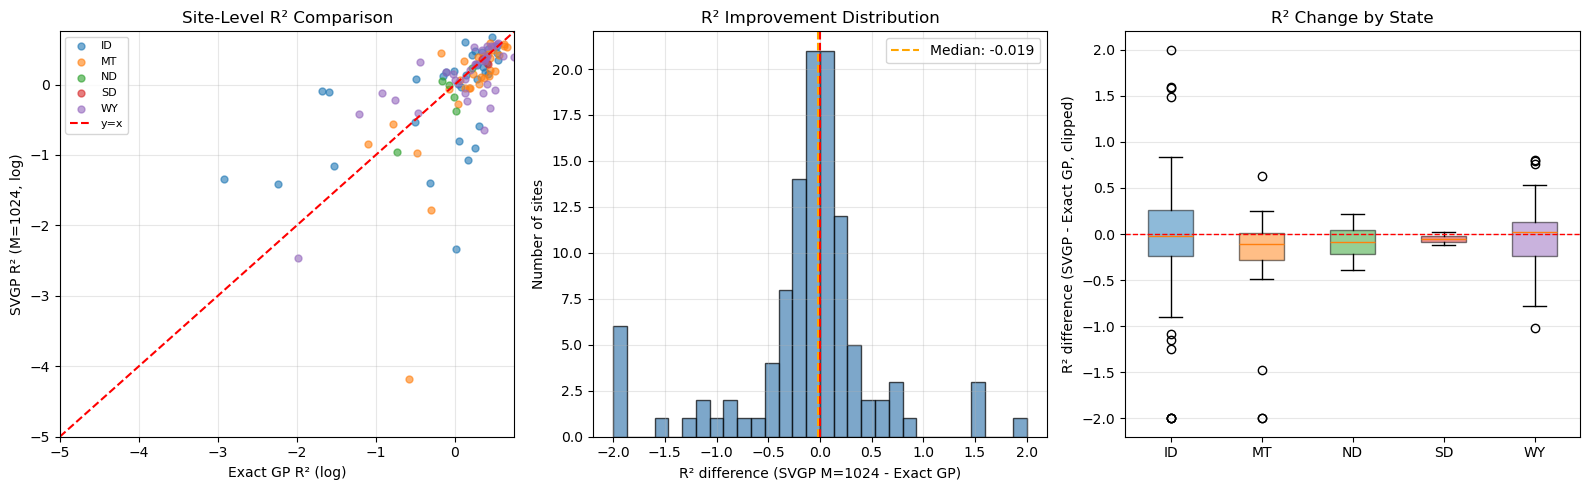

Sites where SVGP (M=1024) improves over Exact GP: 50/112 (44.6%)
Median R² change: -0.0191
Mean R² change:   -0.1901

Per-state breakdown:
 State   Improved   Median dR²     Mean dR²
--------------------------------------------
    ID    17/38        -0.0226      -0.1982
    MT    11/32        -0.1044      -0.3884
    ND     3/6         -0.0846      -0.0845
    SD     1/2         -0.0510      -0.0510
    WY    18/34         0.0259      -0.0210


In [10]:
max_m = max(inducing_list)
svgp_site = site_df[site_df['n_inducing'] == max_m][['site', 'state', 'n_test', 'rmse_log', 'r2_log']].copy()
svgp_site = svgp_site.rename(columns={'rmse_log': 'svgp_rmse', 'r2_log': 'svgp_r2'})

baseline_site = baseline_site_df[['site', 'rmse_log', 'r2_log']].copy()
baseline_site = baseline_site.rename(columns={'rmse_log': 'baseline_rmse', 'r2_log': 'baseline_r2'})

comp = svgp_site.merge(baseline_site, on='site', how='inner')
comp['r2_diff'] = comp['svgp_r2'] - comp['baseline_r2']
comp['rmse_diff'] = comp['svgp_rmse'] - comp['baseline_rmse']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: SVGP R² vs Baseline R²
for i, st in enumerate(states):
    mask = comp['state'] == st
    axes[0].scatter(comp.loc[mask, 'baseline_r2'], comp.loc[mask, 'svgp_r2'],
                    alpha=0.6, label=st, color=colors[i], s=25)
lim_min = min(comp['baseline_r2'].min(), comp['svgp_r2'].min())
lim_max = max(comp['baseline_r2'].max(), comp['svgp_r2'].max())
lim_min = max(lim_min, -5)  # clip for visibility
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=1.5, label='y=x')
axes[0].set_xlabel('Exact GP R² (log)')
axes[0].set_ylabel(f'SVGP R² (M={max_m}, log)')
axes[0].set_title('Site-Level R² Comparison')
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# R² difference histogram
axes[1].hist(comp['r2_diff'].clip(-2, 2), bins=30, edgecolor='black', alpha=0.7,
             color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--', lw=1.5)
axes[1].axvline(x=comp['r2_diff'].median(), color='orange', linestyle='--',
                label=f'Median: {comp["r2_diff"].median():.3f}')
axes[1].set_xlabel(f'R² difference (SVGP M={max_m} - Exact GP)')
axes[1].set_ylabel('Number of sites')
axes[1].set_title('R² Improvement Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Per-state R² difference box plot
state_diff_data = [comp[comp['state'] == st]['r2_diff'].clip(-2, 2).values for st in states]
bp = axes[2].boxplot(state_diff_data, labels=states, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[2].axhline(y=0, color='r', linestyle='--', lw=1)
axes[2].set_ylabel(f'R² difference (SVGP - Exact GP, clipped)')
axes[2].set_title('R² Change by State')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary stats
n_improved = (comp['r2_diff'] > 0).sum()
n_total = len(comp)
print(f"Sites where SVGP (M={max_m}) improves over Exact GP: {n_improved}/{n_total} "
      f"({100*n_improved/n_total:.1f}%)")
print(f"Median R² change: {comp['r2_diff'].median():.4f}")
print(f"Mean R² change:   {comp['r2_diff'].mean():.4f}")
print()
print("Per-state breakdown:")
print(f"{'State':>6} {'Improved':>10} {'Median dR²':>12} {'Mean dR²':>12}")
print('-' * 44)
for st in states:
    st_comp = comp[comp['state'] == st]
    n_imp = (st_comp['r2_diff'] > 0).sum()
    print(f"{st:>6} {n_imp:>5}/{len(st_comp):<4} {st_comp['r2_diff'].median():>12.4f} "
          f"{st_comp['r2_diff'].mean():>12.4f}")

### Prediction Scatter Comparison

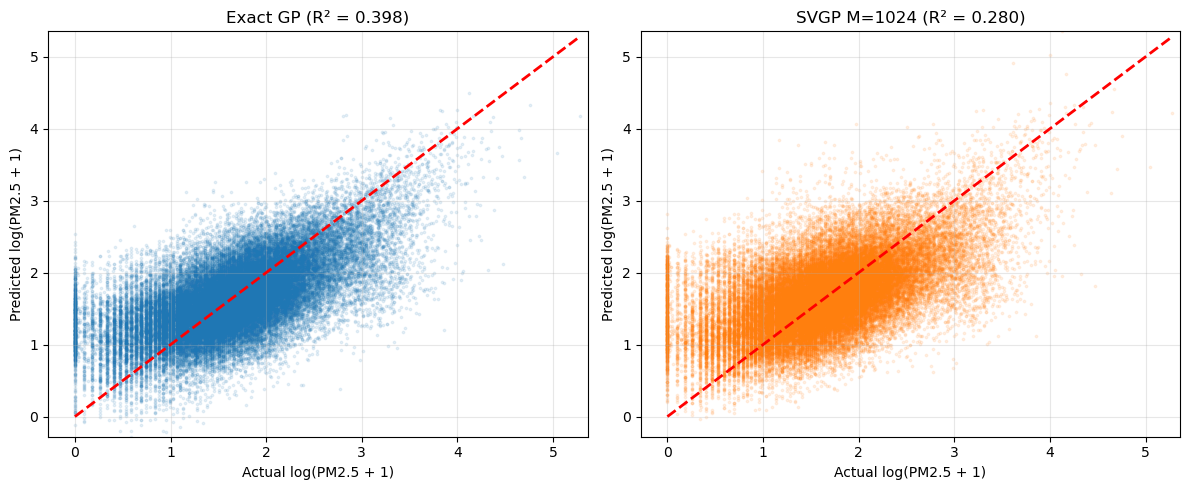

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Exact GP
b_pred = baseline_data['predictions']
b_actual = baseline_data['actuals']
axes[0].scatter(b_actual, b_pred, alpha=0.1, s=3, color='C0')
axes[0].plot([b_actual.min(), b_actual.max()],
             [b_actual.min(), b_actual.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'Exact GP (R² = {bo["r2_log"]:.3f})')
axes[0].grid(True, alpha=0.3)

# SVGP
s_pred = data['predictions']
s_actual = data['actuals']
s_r2 = 1 - np.sum((s_actual - s_pred)**2) / np.sum((s_actual - np.mean(s_actual))**2)
axes[1].scatter(s_actual, s_pred, alpha=0.1, s=3, color='C1')
axes[1].plot([s_actual.min(), s_actual.max()],
             [s_actual.min(), s_actual.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual log(PM2.5 + 1)')
axes[1].set_ylabel('Predicted log(PM2.5 + 1)')
axes[1].set_title(f'SVGP M={max_m} (R² = {s_r2:.3f})')
axes[1].grid(True, alpha=0.3)

# Match axis limits
all_vals = np.concatenate([b_actual, b_pred, s_actual, s_pred])
vmin, vmax = all_vals.min(), all_vals.max()
for ax in axes:
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

plt.tight_layout()
plt.show()

### Kernel Parameter Comparison

Do the SVGP and exact GP learn similar kernel parameters?

In [12]:
baseline_params_df = pd.read_csv(f'{baseline_dir}/daily_parallel_kernel_params.csv')

max_m = max(inducing_list)
svgp_params = site_df[site_df['n_inducing'] == max_m].copy()

param_pairs = [
    ('base_scale', 'param_base_scale', 'Base Scale'),
    ('summer_scale', 'param_summer_scale', 'Summer Scale'),
    ('winter_scale', 'param_winter_scale', 'Winter Scale'),
    ('seasonal_scale', 'param_seasonal_scale', 'Seasonal Scale'),
    ('noise', 'param_noise', 'Noise'),
]

print(f"Kernel parameter comparison (mean across sites):")
print(f"{'Parameter':<20} {'Exact GP':>12} {'SVGP M=' + str(max_m):>16}")
print('-' * 50)
for bl_col, svgp_col, label in param_pairs:
    bl_mean = baseline_params_df[bl_col].mean()
    sv_mean = svgp_params[svgp_col].mean()
    print(f"{label:<20} {bl_mean:>12.4f} {sv_mean:>16.4f}")

period_pairs = [
    ('aot_period_days', 'param_aot_period_days', 'AOT Period'),
    ('smog_period_days', 'param_smog_period_days', 'Smog Period'),
    ('residual_period_days', 'param_residual_period_days', 'Residual Period'),
]
print()
for bl_col, svgp_col, label in period_pairs:
    bl_mean = baseline_params_df[bl_col].mean()
    sv_mean = svgp_params[svgp_col].mean()
    print(f"{label:<20} {bl_mean:>12.1f} {sv_mean:>16.1f}")

Kernel parameter comparison (mean across sites):
Parameter                Exact GP      SVGP M=1024
--------------------------------------------------
Base Scale                 0.0980           0.2072
Summer Scale               0.0480           0.4730
Winter Scale               0.2810           0.3994
Seasonal Scale             0.1109           0.6227
Noise                      0.1320           0.1839

AOT Period                  365.3            331.9
Smog Period                 365.3            489.7
Residual Period             365.3            420.4


---
# Timing Analysis

Detailed breakdown of computational costs to inform scaling decisions.

/tmp/ipykernel_2731730/2255126555.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(train_data, labels=[str(m) for m in sorted(inducing_list)],


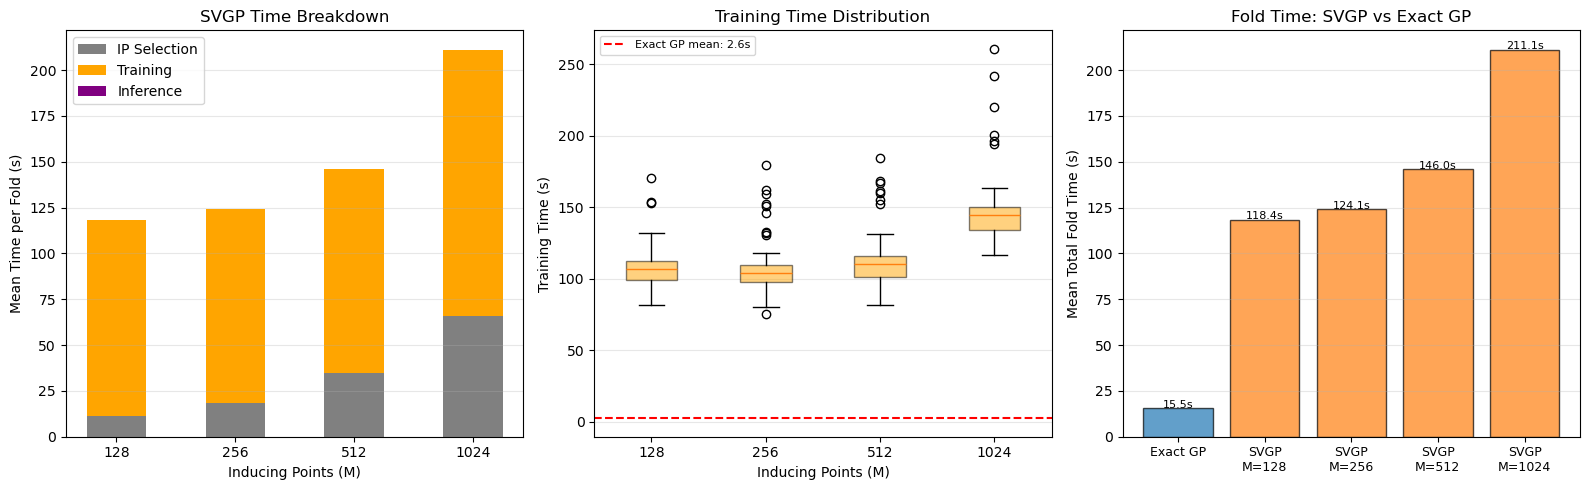

In [13]:
# Per-M timing breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Stacked bar: time breakdown per M
bar_width = 0.5
x_pos = range(len(inducing_list))
ip_times = summary_df['mean_ip_time'].values
train_times = summary_df['mean_train_time'].values
infer_times = summary_df['mean_infer_time'].values

axes[0].bar(x_pos, ip_times, bar_width, label='IP Selection', color='gray')
axes[0].bar(x_pos, train_times, bar_width, bottom=ip_times, label='Training', color='orange')
axes[0].bar(x_pos, infer_times, bar_width, bottom=ip_times + train_times, label='Inference', color='purple')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(int(m)) for m in summary_df['n_inducing']])
axes[0].set_xlabel('Inducing Points (M)')
axes[0].set_ylabel('Mean Time per Fold (s)')
axes[0].set_title('SVGP Time Breakdown')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Training time distribution per M
train_data = [timing_df[timing_df['n_inducing'] == m]['train_time'].values
              for m in sorted(inducing_list)]
bp = axes[1].boxplot(train_data, labels=[str(m) for m in sorted(inducing_list)],
                     patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('orange')
    patch.set_alpha(0.5)
# Add baseline reference
axes[1].axhline(y=baseline_timing_df['train_time'].mean(), color='r', linestyle='--',
                label=f'Exact GP mean: {baseline_timing_df["train_time"].mean():.1f}s')
axes[1].set_xlabel('Inducing Points (M)')
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Training Time Distribution')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

# Total fold time comparison: SVGP vs Exact GP
svgp_fold_means = [timing_df[timing_df['n_inducing'] == m]['total_fold_time'].mean()
                   for m in sorted(inducing_list)]
baseline_fold_mean = baseline_timing_df['fold_time'].mean()

x = list(range(len(inducing_list) + 1))
heights = [baseline_fold_mean] + svgp_fold_means
labels = ['Exact GP'] + [f'SVGP\nM={m}' for m in sorted(inducing_list)]
bar_colors = ['C0'] + ['C1'] * len(inducing_list)

axes[2].bar(x, heights, color=bar_colors, alpha=0.7, edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, fontsize=9)
axes[2].set_ylabel('Mean Total Fold Time (s)')
axes[2].set_title('Fold Time: SVGP vs Exact GP')
axes[2].grid(True, alpha=0.3, axis='y')

for i, h in enumerate(heights):
    axes[2].text(i, h + 0.3, f'{h:.1f}s', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### Scaling Projections

Cost scaling analysis: how do SVGP costs grow with M, and what does this
imply for scaling to the full national dataset (~2M observations)?

In [ ]:
# Fit power-law scaling: time ~ M^alpha
from numpy.polynomial import polynomial as P

m_vals = np.array(sorted(inducing_list), dtype=float)
train_times_mean = np.array([
    timing_df[timing_df['n_inducing'] == m]['train_time'].mean()
    for m in m_vals
])
infer_times_mean = np.array([
    timing_df[timing_df['n_inducing'] == m]['infer_time'].mean()
    for m in m_vals
])

# Log-log fit for train time
log_m = np.log(m_vals)
log_train = np.log(train_times_mean)
log_infer = np.log(infer_times_mean)

train_fit = np.polyfit(log_m, log_train, 1)
infer_fit = np.polyfit(log_m, log_infer, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time scaling (log-log)
axes[0].scatter(m_vals, train_times_mean, s=80, zorder=5, color='orange', edgecolors='black')
m_fit = np.linspace(m_vals.min() * 0.8, m_vals.max() * 4, 100)
axes[0].plot(m_fit, np.exp(train_fit[1]) * m_fit**train_fit[0], '--', color='orange',
             label=f'Fit: t ~ M^{train_fit[0]:.2f}')
axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log')
axes[0].set_xlabel('Inducing Points (M)')
axes[0].set_ylabel('Training Time per Fold (s)')
axes[0].set_title('Training Time Scaling')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Inference time scaling (log-log)
axes[1].scatter(m_vals, infer_times_mean, s=80, zorder=5, color='purple', edgecolors='black')
axes[1].plot(m_fit, np.exp(infer_fit[1]) * m_fit**infer_fit[0], '--', color='purple',
             label=f'Fit: t ~ M^{infer_fit[0]:.2f}')
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log')
axes[1].set_xlabel('Inducing Points (M)')
axes[1].set_ylabel('Inference Time per Fold (s)')
axes[1].set_title('Inference Time Scaling')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scaling projections
n_current = 48000
n_national = 2_000_000
n_sites_current = 112
n_sites_national = 976
scale_factor = n_national / n_current

print(f"Empirical scaling exponents:")
print(f"  Training time ~ M^{train_fit[0]:.2f}")
print(f"  Inference time ~ M^{infer_fit[0]:.2f}")
print()
print(f"Scaling projections (current: {n_current:,} obs, {n_sites_current} sites):")
print(f"{'':>20} {'Current (5-state)':>20} {'National (~2M obs)':>20}")
print('-' * 62)

# SVGP training time scales as O(N * M^2) per epoch, so linearly in N
# (mini-batch training sees all data in N/batch_size steps)
for m in sorted(inducing_list):
    current_train = timing_df[timing_df['n_inducing'] == m]['train_time'].mean()
    # Training scales linearly with N (more mini-batches per epoch)
    proj_train = current_train * scale_factor
    # Inference is O(M^2) per test point, independent of N
    current_infer = timing_df[timing_df['n_inducing'] == m]['infer_time'].mean()

    print(f"  M={m:<5} train   {current_train:>18.1f}s {proj_train:>18.1f}s ({proj_train/60:.0f}m)")
    print(f"  M={m:<5} infer   {current_infer:>18.3f}s {current_infer:>18.3f}s (same)")

print()
print("Note: SVGP training scales linearly with N (more mini-batches per epoch).")
print("Inference cost depends only on M and test size, not training set size.")
print(f"National dataset would also need {n_sites_national} LOSO folds vs {n_sites_current} currently.")

### Detailed Timing Table

In [ ]:
print("Detailed timing comparison:")
print()
print("EXACT GP BASELINE (daily batch SGD):")
print(f"  Mean train time/fold:   {baseline_timing_df['train_time'].mean():.2f}s")
print(f"  Mean fold time (w/sweep): {baseline_timing_df['fold_time'].mean():.2f}s")
print(f"  Total CV wall time:     {bo['total_time']:.1f}s ({bo['total_time']/60:.1f} min)")
print(f"  Training method:        ExactGP + daily batch SGD (~66 obs/batch)")
print(f"  Inference method:       ExactGP conditioning (sweep 25-400 days)")
print()
print("SVGP:")
for m in sorted(inducing_list):
    t = timing_df[timing_df['n_inducing'] == m]
    s = summary_df[summary_df['n_inducing'] == m].iloc[0]
    print(f"  M={m}:")
    print(f"    IP selection:       {t['ip_selection_time'].mean():.2f}s  (k-means)")
    print(f"    Training:           {t['train_time'].mean():.2f}s  "
          f"(mean {t['stopped_epoch'].mean():.0f} epochs)")
    print(f"    Inference:          {t['infer_time'].mean():.3f}s")
    print(f"    Total per fold:     {t['total_fold_time'].mean():.2f}s")
    print(f"    Sum across folds:   {t['total_fold_time'].sum():.1f}s")
    print()

# Efficiency: R² per second
print("Efficiency (R²_log per second of training):")
print(f"  Exact GP:    R²={bo['r2_log']:.4f} in {bo['total_time']:.0f}s → "
      f"{bo['r2_log']/bo['total_time']*1000:.4f} R²/ks")
for _, row in summary_df.iterrows():
    m = int(row['n_inducing'])
    print(f"  SVGP M={m:<4}: R²={row['r2_log']:.4f} in {row['total_wall_time']:.0f}s → "
          f"{row['r2_log']/row['total_wall_time']*1000:.4f} R²/ks")

### Accuracy vs Cost Pareto

Joint view: is SVGP a worthwhile tradeoff compared to exact GP?

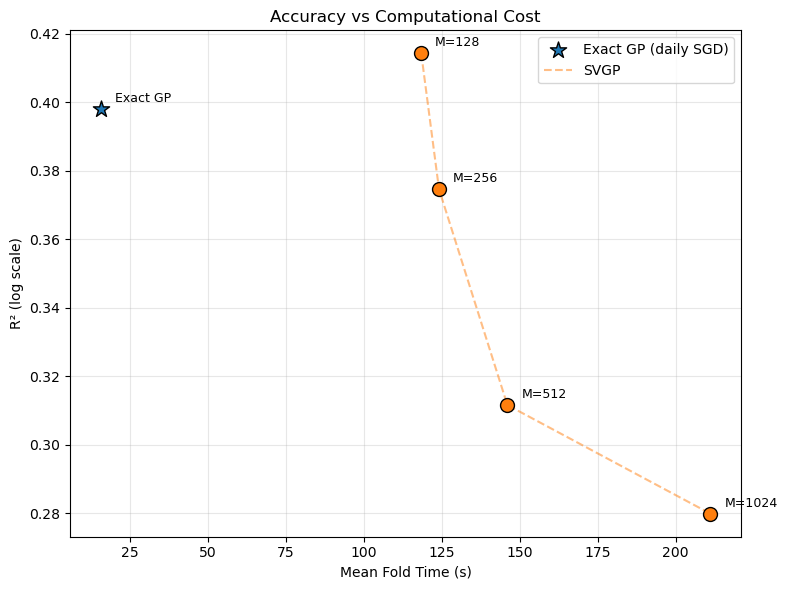

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Exact GP baseline
baseline_mean_fold = baseline_timing_df['fold_time'].mean()
ax.scatter(baseline_mean_fold, bo['r2_log'], s=150, marker='*', color='C0',
           edgecolors='black', zorder=10, label='Exact GP (daily SGD)')
ax.annotate('Exact GP', (baseline_mean_fold, bo['r2_log']),
            textcoords="offset points", xytext=(10, 5), fontsize=9)

# SVGP points
for _, row in summary_df.iterrows():
    m = int(row['n_inducing'])
    ax.scatter(row['mean_fold_time'], row['r2_log'], s=100, marker='o',
               color='C1', edgecolors='black', zorder=10)
    ax.annotate(f'M={m}', (row['mean_fold_time'], row['r2_log']),
                textcoords="offset points", xytext=(10, 5), fontsize=9)

# Connect SVGP points
ax.plot(summary_df['mean_fold_time'], summary_df['r2_log'], '--', color='C1',
        alpha=0.5, label='SVGP')

ax.set_xlabel('Mean Fold Time (s)')
ax.set_ylabel('R² (log scale)')
ax.set_title('Accuracy vs Computational Cost')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()